# NeurIPS Publication Figure Generation Evaluation

This notebook regenerates **8 NeurIPS publication-quality figures** from 5 experiment
dependencies and computes per-figure and aggregate quality metrics.

**Figures:** CSD Framework Overview, Accuracy vs Difficulty, CSD Indicator Profiles,
Temperature-Dependent CSD, Classifier Comparison (LOPO/LOTO/Cost), Model Fits,
Aggregate Model Comparison, Prospective Protocol Results.

**Metrics:** File size (target 87-468 KB), NeurIPS dimension compliance
(single 3.25 in, double 6.75 in +/-0.5 in), total data points plotted.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru')

# Core packages — pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.5.2',
         'scipy==1.14.1', 'matplotlib==3.10.0', 'Pillow==11.1.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
from loguru import logger
from PIL import Image

# Logging setup
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-276cb0-flickering-before-failing-ecological-cri/main/evaluation_iter6_regenerate_8_pu/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with keys: {list(data.keys())}")
for key in sorted(data.keys()):
    n_ds = len(data[key].get('datasets', []))
    n_ex = sum(len(ds.get('examples', [])) for ds in data[key].get('datasets', []))
    print(f"  {key}: {n_ds} datasets, {n_ex} examples")

Loaded data with keys: ['dep1', 'dep2', 'dep3', 'dep4', 'dep5']
  dep1: 3 datasets, 9 examples
  dep2: 3 datasets, 6 examples
  dep3: 0 datasets, 0 examples
  dep4: 0 datasets, 0 examples
  dep5: 3 datasets, 7 examples


In [5]:
# ═══ Configuration ═══
# Adjust these to control demo scope and speed

MAX_FIGURES = 8       # Number of figures to generate (1-8); Original: 8
DPI = 150             # Figure resolution; Original: 300

# NeurIPS dimensions (inches) — fixed
SINGLE_COL = 3.25
DOUBLE_COL = 6.75
DIM_TOLERANCE = 0.5

## Data Extraction Helpers

Extract and unify CSD (Critical Slowing Down) indicators from arithmetic and graph
coloring experiments into a single DataFrame.

In [6]:
def extract_arithmetic_levels(dep1: dict) -> pd.DataFrame:
    rows = []
    for ds in dep1.get("datasets", []):
        for ex in ds.get("examples", []):
            rows.append({
                "task": "arithmetic",
                "model": ex.get("metadata_model", ""),
                "model_short": ex.get("metadata_model", "").split("/")[-1],
                "difficulty": ex.get("metadata_difficulty_level"),
                "accuracy": float(ex.get("predict_accuracy", 0)),
                "variance": float(ex.get("predict_csd_variance", 0)),
                "dip": float(ex.get("predict_dip_statistic", 0)),
                "silhouette": float(ex.get("predict_silhouette_k2", 0)),
                "bimodality": float(ex.get("predict_bimodality_coefficient", 0)),
                "disagreement": float(ex.get("predict_disagreement_rate", 0)),
                "d_star": ex.get("metadata_d_star"),
            })
    return pd.DataFrame(rows)


def extract_gc_levels(dep2: dict) -> pd.DataFrame:
    seen: dict = {}
    for ds in dep2.get("datasets", []):
        for ex in ds.get("examples", []):
            key = (ex.get("metadata_model", ""), ex.get("metadata_difficulty_level"))
            if key in seen:
                continue
            seen[key] = {
                "task": "graph_coloring",
                "model": ex.get("metadata_model", ""),
                "model_short": ex.get("metadata_model", "").split("/")[-1],
                "difficulty": ex.get("metadata_difficulty_level"),
                "accuracy": float(ex.get("metadata_csd_accuracy", 0)),
                "variance": float(ex.get("metadata_csd_embedding_variance", 0)),
                "dip": float(ex.get("metadata_csd_dip_statistic", 0)),
                "silhouette": float(ex.get("metadata_csd_silhouette_score", 0)),
                "bimodality": float(ex.get("metadata_csd_bimodality_coefficient", 0)),
                "disagreement": float(ex.get("metadata_csd_disagreement_rate", 0)),
                "d_star": None,
            }
    # fill d_star from metadata
    meta = dep2.get("metadata", {}).get("analysis", {})
    for m_info in meta.get("models", []):
        model = m_info["model"]
        for key in seen:
            if key[0] == model:
                seen[key]["d_star"] = m_info.get("d_star")
    return pd.DataFrame(list(seen.values()))


def build_unified_csd(dep1: dict, dep2: dict) -> pd.DataFrame:
    df = pd.concat([extract_arithmetic_levels(dep1),
                     extract_gc_levels(dep2)], ignore_index=True)
    df["label"] = df.apply(
        lambda r: "near" if r["d_star"] is not None
                          and r["difficulty"] >= r["d_star"] - 3
                  else "safe", axis=1)
    df["label_binary"] = (df["label"] == "near").astype(int)
    label_counts = df["label"].value_counts().to_dict()
    logger.info(f"Unified CSD features: {len(df)} rows  {label_counts}")
    return df

## NeurIPS Figure Configuration

Style settings, figure specifications, and color palette for publication-quality figures.

In [7]:
# Workspace and output directory
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

FIGURE_SPECS = [
    {"name": "fig1_csd_framework",
     "title": "Figure 1: CSD Framework Overview",
     "width": SINGLE_COL, "type": "conceptual", "deps": []},
    {"name": "fig2_accuracy_curves",
     "title": "Figure 2: Accuracy vs Difficulty",
     "width": SINGLE_COL, "type": "empirical", "deps": [1, 2]},
    {"name": "fig3_csd_indicators",
     "title": "Figure 3: CSD Indicator Profiles",
     "width": DOUBLE_COL, "type": "empirical", "deps": [1, 2]},
    {"name": "fig4_temperature",
     "title": "Figure 4: Temperature-Dependent CSD",
     "width": DOUBLE_COL, "type": "empirical", "deps": [4]},
    {"name": "fig5_classifier_comparison",
     "title": "Figure 5: Classifier Comparison (LOPO/LOTO/Cost)",
     "width": DOUBLE_COL, "type": "empirical", "deps": [3]},
    {"name": "fig6_model_fits_gc_gemini",
     "title": "Figure 6: Model Fits gc x gemini-flash",
     "width": SINGLE_COL, "type": "empirical", "deps": [5]},
    {"name": "fig7_aggregate_models",
     "title": "Figure 7: Aggregate Model Comparison",
     "width": DOUBLE_COL, "type": "empirical", "deps": [5]},
    {"name": "fig8_prospective_protocol",
     "title": "Figure 8: Prospective Protocol Results",
     "width": DOUBLE_COL, "type": "empirical", "deps": [1, 2, 3]},
]

NEURIPS_RC = {
    "font.family": "serif", "font.size": 8,
    "axes.labelsize": 8, "axes.titlesize": 9,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 6,
    "figure.dpi": DPI, "savefig.dpi": DPI,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
}

COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
]

def _save_figure(fig, name):
    png = FIGURES_DIR / f"{name}.png"
    pdf = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(str(png), dpi=DPI, bbox_inches="tight", pad_inches=0.02)
    fig.savefig(str(pdf), bbox_inches="tight", pad_inches=0.02)
    logger.info(f"  Saved {png.name} ({png.stat().st_size / 1024:.1f} KB)")

## Figure Generation Functions

Eight generators producing NeurIPS-compliant publication figures. Each returns
metadata about the number of data points plotted.

In [8]:
def gen_fig1_framework(spec):
    """Conceptual CSD Framework Overview."""
    w, h = spec["width"], spec["width"] * 0.85
    fig, ax = plt.subplots(figsize=(w, h))
    ax.set_xlim(0, 10); ax.set_ylim(0, 8.5); ax.set_axis_off()
    ax.text(5, 8.1, "CSD Framework for LLM Capability Boundary Detection",
            ha="center", va="top", fontsize=7, fontweight="bold")
    # Box 1 - Sampling
    ax.add_patch(FancyBboxPatch((0.3, 5.5), 2.8, 2.0,
        boxstyle="round,pad=0.1", fc="#E3F2FD", ec="#1565C0", lw=1.2))
    ax.text(1.7, 7.1, "1. LLM Sampling", ha="center", fontsize=6.5, fontweight="bold")
    ax.text(1.7, 6.5, "N responses per\ndifficulty level d", ha="center", fontsize=5.5)
    ax.text(1.7, 5.8, "T, top_p fixed", ha="center", fontsize=5, style="italic", color="gray")
    # Box 2 - Indicators
    ax.add_patch(FancyBboxPatch((3.8, 5.5), 2.8, 2.0,
        boxstyle="round,pad=0.1", fc="#E8F5E9", ec="#2E7D32", lw=1.2))
    ax.text(5.2, 7.1, "2. CSD Indicators", ha="center", fontsize=6.5, fontweight="bold")
    ax.text(5.2, 6.4, "Variance, Dip,\nBimodality, BC,\nDisagreement",
            ha="center", fontsize=5.5)
    # Box 3 - Classifier
    ax.add_patch(FancyBboxPatch((7.1, 5.5), 2.5, 2.0,
        boxstyle="round,pad=0.1", fc="#FFF3E0", ec="#E65100", lw=1.2))
    ax.text(8.35, 7.1, "3. Classifier", ha="center", fontsize=6.5, fontweight="bold")
    ax.text(8.35, 6.4, "z-score norm +\nRelDist features\nRF / LogReg / SVM",
            ha="center", fontsize=5.5)
    # Box 4 - Prospective
    ax.add_patch(FancyBboxPatch((2.5, 1.5), 5.0, 2.8,
        boxstyle="round,pad=0.1", fc="#F3E5F5", ec="#6A1B9A", lw=1.2))
    ax.text(5.0, 3.9, "4. Prospective Protocol", ha="center",
            fontsize=6.5, fontweight="bold")
    ax.text(5.0, 3.2, "Deploy: Monitor CSD indicators in real-time",
            ha="center", fontsize=5.5)
    ax.text(5.0, 2.6, "any-1 | CUSUM | d*-free LR", ha="center",
            fontsize=5.5, fontweight="bold", color="#6A1B9A")
    ax.text(5.0, 2.0,
            "Flag approaching capability boundary\nwithout knowing d* in advance",
            ha="center", fontsize=5, style="italic")
    # Arrows
    for xy, xytext in [((3.9, 6.5), (3.1, 6.5)),
                        ((7.2, 6.5), (6.6, 6.5)),
                        ((5.0, 4.35), (5.0, 5.5))]:
        ax.annotate("", xy=xy, xytext=xytext,
                     arrowprops=dict(arrowstyle="->", color="#333", lw=1.2))
    ax.text(5.0, 0.8,
            "Zero extra API cost | LOPO F1=0.95 | LOTO F1=0.94",
            ha="center", fontsize=5.5, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", fc="#FFEB3B", alpha=0.7))
    _save_figure(fig, spec["name"])
    plt.close(fig)
    return {"n_data_points": 0}


def gen_fig2_accuracy(spec, df):
    """Accuracy vs Difficulty curves for all model-task pairs."""
    w, h = spec["width"], spec["width"] * 1.2
    fig, axes = plt.subplots(2, 1, figsize=(w, h))
    n_pts = 0
    for panel, (ax, task, title) in enumerate(zip(
            axes, ["arithmetic", "graph_coloring"],
            ["(a) Multi-Step Arithmetic", "(b) Graph Coloring"])):
        sub = df[df["task"] == task].copy()
        for i, (model, grp) in enumerate(sub.groupby("model_short")):
            g = grp.sort_values("difficulty")
            ax.plot(g["difficulty"], g["accuracy"],
                    marker="o", ms=2.5, lw=1.2, color=COLORS[i], label=model)
            ds = g["d_star"].iloc[0]
            if ds is not None:
                ax.axvline(ds, color=COLORS[i], ls="--", alpha=0.4, lw=0.8)
            n_pts += len(g)
        ax.set_ylabel("Accuracy")
        ax.set_title(title, fontsize=8)
        ax.legend(loc="upper right", fontsize=5)
        ax.set_ylim(-0.05, 1.05)
    axes[1].set_xlabel("Difficulty Level (d)")
    fig.tight_layout()
    _save_figure(fig, spec["name"])
    plt.close(fig)
    return {"n_data_points": n_pts}


def gen_fig3_indicators(spec, df):
    """CSD Indicator Profiles (4-panel)."""
    w, h = spec["width"], spec["width"] * 0.5
    indicators = ["variance", "dip", "bimodality", "disagreement"]
    labels = ["Embedding Variance", "Dip Statistic",
              "Bimodality Coeff.", "Disagreement Rate"]
    fig, axes = plt.subplots(1, 4, figsize=(w, h), sharey=False)
    n_pts = 0
    pairs = list(df.groupby(["task", "model_short"]).groups.keys())
    for col, (ind, lab) in enumerate(zip(indicators, labels)):
        ax = axes[col]
        for i, (task, model) in enumerate(pairs):
            g = df[(df["task"] == task) & (df["model_short"] == model)].sort_values("difficulty")
            short = f"{task[:5]}:{model[:12]}"
            ax.plot(g["difficulty"], g[ind], marker=".", ms=2, lw=0.8,
                    color=COLORS[i % len(COLORS)], label=short, alpha=0.8)
            n_pts += len(g)
        ax.set_xlabel("d", fontsize=6)
        ax.set_title(lab, fontsize=7)
        if col == 0:
            ax.set_ylabel("Indicator Value", fontsize=6)
    handles, lbls = axes[0].get_legend_handles_labels()
    fig.legend(handles, lbls, loc="lower center", ncol=3, fontsize=4.5,
               bbox_to_anchor=(0.5, -0.12))
    fig.tight_layout()
    _save_figure(fig, spec["name"])
    plt.close(fig)
    return {"n_data_points": n_pts}


def gen_fig4_temperature(spec, dep4):
    """Temperature-Dependent CSD Flickering."""
    w, h = spec["width"], spec["width"] * 0.45
    meta = dep4.get("metadata", {})
    ta = meta.get("per_temperature_analysis", {})
    temps = sorted(ta.keys(), key=float)
    fig, axes = plt.subplots(1, 4, figsize=(w, h))
    n_pts = 0
    tau_keys = ["tau_variance", "tau_dip", "tau_silhouette", "tau_disagreement"]
    tau_labels = ["Variance (tau)", "Dip (tau)", "Silhouette (tau)", "Disagreement (tau)"]
    for idx in range(3):
        ax = axes[idx]
        vals = [ta[t].get(tau_keys[idx], 0) or 0 for t in temps]
        ax.bar(range(len(temps)), vals,
               color=[COLORS[j] for j in range(len(temps))], alpha=0.8, width=0.6)
        ax.set_xticks(range(len(temps)))
        ax.set_xticklabels([f"T={t}" for t in temps], fontsize=5, rotation=30)
        ax.set_title(tau_labels[idx], fontsize=7)
        if idx == 0:
            ax.set_ylabel("Kendall tau")
        ax.axhline(0, color="gray", lw=0.5)
        n_pts += len(temps)
    # d* vs temperature
    ax = axes[3]
    d_stars = [ta[t].get("d_star", 0) for t in temps]
    ax.plot([float(t) for t in temps], d_stars, "o-",
            color=COLORS[0], ms=4, lw=1.5)
    ax.set_xlabel("Temperature", fontsize=6)
    ax.set_ylabel("d*", fontsize=6)
    ax.set_title("d* vs Temperature", fontsize=7)
    n_pts += len(temps)
    dose = meta.get("dose_response_analysis", {})
    score = dose.get("csd_evidence_score", 0)
    fig.suptitle(f"Temperature Manipulation (CSD Evidence={score:.2f})",
                 fontsize=8, y=1.02)
    fig.tight_layout()
    _save_figure(fig, spec["name"])
    plt.close(fig)
    return {"n_data_points": n_pts}


def _classify_variant(variant):
    v = variant.lower()
    if "spuq" in v and "csd" not in v:
        return "spuq"
    if any(x in v for x in ("variance_only", "disagreement_only",
                             "dip_only", "bimodality_only")):
        return "baseline"
    return "csd"


def gen_fig5_classifier(spec, dep3):
    """Classifier Comparison - 3-panel: LOPO, LOTO, cost comparison."""
    w, h = spec["width"], spec["width"] * 0.42
    fig, axes = plt.subplots(1, 3, figsize=(w, h),
                              gridspec_kw={"width_ratios": [3, 3, 2]})
    meta = dep3.get("metadata", {})
    cc = meta.get("classifier_comparison", {})
    n_pts = 0
    entries = []
    for key, vals in cc.items():
        if not isinstance(vals, dict):
            continue
        entries.append({
            "key": key, "variant": vals.get("classifier_variant", key),
            "model_type": vals.get("model_type", ""),
            "lopo_f1": vals.get("lopo_f1", 0),
            "loto_f1": vals.get("loto_f1", 0),
            "category": _classify_variant(vals.get("classifier_variant", key)),
        })
    best_per = {}
    for e in entries:
        v = e["variant"]
        if v not in best_per or e["lopo_f1"] > best_per[v]["lopo_f1"]:
            best_per[v] = e
    sorted_all = sorted(best_per.values(), key=lambda x: x["lopo_f1"], reverse=True)
    top_show = sorted_all[:10]
    # Panel A: LOPO
    ax = axes[0]
    show = sorted(top_show, key=lambda x: x["lopo_f1"])
    bar_colors = {"csd": "#1f77b4", "spuq": "#ff7f0e", "baseline": "#7f7f7f"}
    y_pos = range(len(show))
    ax.barh(y_pos, [e["lopo_f1"] for e in show],
            color=[bar_colors[e["category"]] for e in show], alpha=0.85, height=0.7)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([f'{e["variant"]} ({e["model_type"]})' for e in show], fontsize=4.5)
    ax.set_xlabel("F1 Score", fontsize=6)
    ax.set_title("(a) Within-Task LOPO", fontsize=7, fontweight="bold")
    ax.set_xlim(0, 1.05)
    n_pts += len(show)
    # Panel B: LOTO
    ax = axes[1]
    loto_show = [e for e in sorted_all if e["loto_f1"] > 0.1][:10]
    loto_show = sorted(loto_show, key=lambda x: x["loto_f1"])
    loto_colors = {"csd": "#2ca02c", "spuq": "#ff7f0e", "baseline": "#7f7f7f"}
    y_pos = range(len(loto_show))
    ax.barh(y_pos, [e["loto_f1"] for e in loto_show],
            color=[loto_colors[e["category"]] for e in loto_show], alpha=0.85, height=0.7)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([f'{e["variant"]} ({e["model_type"]})' for e in loto_show], fontsize=4.5)
    ax.set_xlabel("F1 Score", fontsize=6)
    ax.set_title("(b) Cross-Task LOTO", fontsize=7, fontweight="bold")
    ax.set_xlim(0, 1.05)
    n_pts += len(loto_show)
    # Panel C: Cost comparison
    ax = axes[2]
    cost_info = meta.get("cost_analysis", {})
    best_csd_key = meta.get("best_csd_method", "csd_zt_reldist_rf")
    best_spuq_key = meta.get("best_spuq_method", "spuq_accuracy_rf")
    best_csd_f1 = (cc.get(best_csd_key, {}).get("lopo_f1", 0)
                   if isinstance(cc.get(best_csd_key), dict) else 0)
    best_spuq_f1 = (cc.get(best_spuq_key, {}).get("lopo_f1", 0)
                    if isinstance(cc.get(best_spuq_key), dict) else 0)
    methods, costs, f1s = [], [], []
    for mname, cdata in cost_info.items():
        methods.append(mname)
        costs.append(cdata.get("extra_api_calls", 0))
        if "CSD" in mname and "SPUQ" not in mname:
            f1s.append(best_csd_f1)
        elif "SPUQ" in mname and "CSD" not in mname:
            f1s.append(best_spuq_f1)
        else:
            f1s.append(0.86)
    if methods:
        bc = ["#1f77b4", "#ff7f0e", "#9467bd"][:len(methods)]
        bars = ax.bar(range(len(methods)), costs, color=bc, alpha=0.85, width=0.6)
        ax.set_xticks(range(len(methods)))
        ax.set_xticklabels([m.replace(" ", "\n") for m in methods], fontsize=4.5)
        ax.set_ylabel("Extra API Calls", fontsize=6)
        ax.set_title("(c) Cost Comparison", fontsize=7, fontweight="bold")
        for bar, f1 in zip(bars, f1s):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 20,
                    f"F1={f1:.2f}", ha="center", va="bottom",
                    fontsize=4.5, fontweight="bold")
        n_pts += len(methods)
    fig.tight_layout()
    _save_figure(fig, spec["name"])
    plt.close(fig)
    return {"n_data_points": n_pts}


def gen_fig6_model_fits(spec, dep5):
    """Theoretical model fits for gc x gemini-flash."""
    w, h = spec["width"], spec["width"] * 1.1
    per_level, model_comp = None, None
    for ds in dep5.get("datasets", []):
        if ds["dataset"] == "per_level_fits":
            per_level = ds
        elif ds["dataset"] == "model_comparison_all_series":
            model_comp = ds
    rows = []
    if per_level:
        for ex in per_level["examples"]:
            s = ex.get("metadata_series", "")
            if "gc" in s.lower() and "gemini" in s.lower():
                rows.append({
                    "difficulty": ex.get("metadata_difficulty_level"),
                    "observed": float(ex.get("predict_observed_variance", 0)),
                    "mixture": float(ex.get("predict_mixture_predicted", 0)),
                    "fold": float(ex.get("predict_fold_predicted", 0)),
                    "cusp": float(ex.get("predict_cusp_predicted", 0)),
                    "ddm": float(ex.get("predict_ddm_predicted", 0)),
                    "accuracy": float(ex.get("predict_observed_accuracy", 0)),
                })
    if not rows and per_level:
        first_s = per_level["examples"][0].get("metadata_series", "")
        logger.warning(f"gc x gemini-flash not found; falling back to '{first_s}'")
        for ex in per_level["examples"]:
            if ex.get("metadata_series") == first_s:
                rows.append({
                    "difficulty": ex.get("metadata_difficulty_level"),
                    "observed": float(ex.get("predict_observed_variance", 0)),
                    "mixture": float(ex.get("predict_mixture_predicted", 0)),
                    "fold": float(ex.get("predict_fold_predicted", 0)),
                    "cusp": float(ex.get("predict_cusp_predicted", 0)),
                    "ddm": float(ex.get("predict_ddm_predicted", 0)),
                    "accuracy": float(ex.get("predict_observed_accuracy", 0)),
                })
    lvl = pd.DataFrame(rows).sort_values("difficulty")
    fig, axes = plt.subplots(2, 1, figsize=(w, h))
    n_pts = 0
    ax = axes[0]
    ax.scatter(lvl["difficulty"], lvl["observed"], color="black", s=8,
               zorder=5, label="Observed")
    for mdl, clr in zip(["mixture", "cusp", "ddm", "fold"],
                         ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]):
        ax.plot(lvl["difficulty"], lvl[mdl], lw=1.2, color=clr,
                alpha=0.8, label=mdl.capitalize())
    ax.set_ylabel("Embedding Variance", fontsize=7)
    ax.set_title("(a) Variance: Observed vs Predictions", fontsize=7)
    ax.legend(fontsize=5, loc="best")
    n_pts += len(lvl) * 5
    ax = axes[1]
    ax.plot(lvl["difficulty"], lvl["accuracy"], "ko-", ms=3, lw=1.2, label="Accuracy")
    ax.set_xlabel("Difficulty Level (d)", fontsize=7)
    ax.set_ylabel("Accuracy", fontsize=7)
    ax.set_title("(b) Accuracy Curve", fontsize=7)
    ax.set_ylim(-0.05, 1.05)
    n_pts += len(lvl)
    if model_comp:
        for ex in model_comp["examples"]:
            t = ex.get("metadata_task", "")
            m = ex.get("metadata_model", "")
            if ("graph" in t or "gc" in t) and "gemini" in m.lower():
                axes[0].text(0.02, 0.02,
                    f'Mixture R2={ex.get("predict_mixture_R2", "N/A")}',
                    transform=axes[0].transAxes, fontsize=5,
                    bbox=dict(boxstyle="round", fc="wheat", alpha=0.5))
                break
    fig.tight_layout()
    _save_figure(fig, spec["name"])
    plt.close(fig)
    return {"n_data_points": n_pts}


def gen_fig7_aggregate(spec, dep5):
    """Aggregate Model Comparison across all series."""
    w, h = spec["width"], spec["width"] * 0.4
    agg_ds, comp_ds = None, None
    for ds in dep5.get("datasets", []):
        if ds["dataset"] == "aggregate_statistics":
            agg_ds = ds
        elif ds["dataset"] == "model_comparison_all_series":
            comp_ds = ds
    fig, axes = plt.subplots(1, 3, figsize=(w, h))
    n_pts = 0
    models = ["Mixture", "Cusp", "DDM", "Fold"]
    # A - R2 / AIC wins
    ax = axes[0]
    if agg_ds and agg_ds["examples"]:
        agg = agg_ds["examples"][0]
        r2w = [int(agg.get(f"predict_{m.lower()}_r2_wins", 0)) for m in models]
        aicw = [int(agg.get(f"predict_{m.lower()}_aic_wins", 0)) for m in models]
        x = np.arange(len(models))
        bw = 0.35
        ax.bar(x - bw / 2, r2w, bw, label="R2 wins", color="#1f77b4", alpha=0.8)
        ax.bar(x + bw / 2, aicw, bw, label="AIC wins", color="#ff7f0e", alpha=0.8)
        ax.set_xticks(x); ax.set_xticklabels(models, fontsize=6)
        ax.set_ylabel("Wins (out of 10)", fontsize=6)
        ax.set_title("(a) Model Selection Wins", fontsize=7)
        ax.legend(fontsize=5)
        n_pts += len(models) * 2
    # B - Mean R2
    ax = axes[1]
    if agg_ds and agg_ds["examples"]:
        agg = agg_ds["examples"][0]
        keys = ["mixture_mean_R2", "cusp_mean_R2_variance",
                "ddm_mean_R2_variance", "fold_mean_R2"]
        vals = []
        for k in keys:
            try:
                vals.append(float(agg.get(f"predict_{k}", 0)))
            except (ValueError, TypeError):
                vals.append(0.0)
        ax.bar(range(len(models)), vals,
               color=["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"], alpha=0.8)
        ax.set_xticks(range(len(models))); ax.set_xticklabels(models, fontsize=6)
        ax.set_ylabel("Mean R2", fontsize=6)
        ax.set_title("(b) Mean R2 Across Series", fontsize=7)
        ax.axhline(0, color="gray", lw=0.5)
        n_pts += len(models)
    # C - Per-series best model
    ax = axes[2]
    if comp_ds:
        names, r2v, bcol = [], [], []
        model_cm = {"mixture": "#1f77b4", "cusp": "#ff7f0e",
                     "ddm": "#2ca02c", "fold": "#d62728"}
        for ex in comp_ds["examples"]:
            t = ex.get("metadata_task", "")
            m = ex.get("metadata_model", "").split("/")[-1]
            names.append(f"{t[:5]}:{m[:10]}")
            try:
                r2v.append(float(ex.get("predict_mixture_R2", 0)))
            except (ValueError, TypeError):
                r2v.append(0.0)
            bcol.append(model_cm.get(ex.get("predict_best_model_r2", ""), "#7f7f7f"))
        ax.barh(range(len(names)), r2v, color=bcol, alpha=0.8, height=0.6)
        ax.set_yticks(range(len(names)))
        ax.set_yticklabels(names, fontsize=4.5)
        ax.set_xlabel("Mixture R2", fontsize=6)
        ax.set_title("(c) Per-Series Mixture R2", fontsize=7)
        n_pts += len(names)
    fig.tight_layout()
    _save_figure(fig, spec["name"])
    plt.close(fig)
    return {"n_data_points": n_pts}


FEAT_COLS = ["variance", "dip", "silhouette", "bimodality", "disagreement"]

def compute_prospective(df, dep3):
    """Compute three prospective protocols: any-1, CUSUM, d*-free-LR."""
    results = {"protocols": {}, "model_task_pairs": []}
    pairs = list(df.groupby(["task", "model"]).groups.keys())
    results["model_task_pairs"] = [{"task": t, "model": m} for t, m in pairs]
    y = df["label_binary"].values
    if len(df) < 5 or df["label_binary"].nunique() < 2:
        logger.warning("Insufficient data for prospective protocols")
        for k in ("any_1", "cusum", "d_star_free_lr"):
            results["protocols"][k] = {"f1": 0.0, "precision": 0.0, "recall": 0.0}
        return results
    # any-1
    safe = df[df["label"] == "safe"]
    thresholds = {}
    for c in FEAT_COLS:
        v = safe[c].dropna()
        thresholds[c] = (v.mean() + 1.0 * v.std()) if len(v) > 0 else 1.0
    any1 = np.array([
        int(any(row[c] >= thresholds[c] for c in FEAT_COLS))
        for _, row in df.iterrows()
    ])
    results["protocols"]["any_1"] = {
        "f1": float(f1_score(y, any1, zero_division=0)),
        "precision": float(precision_score(y, any1, zero_division=0)),
        "recall": float(recall_score(y, any1, zero_division=0)),
    }
    # CUSUM
    cusum_pred = np.zeros(len(df), dtype=int)
    for task, model in pairs:
        mask = (df["task"] == task) & (df["model"] == model)
        sub = df[mask].sort_values("difficulty")
        if len(sub) < 3:
            continue
        vs = sub["variance"].values
        mu = vs[: max(3, len(vs) // 3)].mean()
        cs = np.cumsum(vs - mu)
        thr = 2.0 * vs.std() if vs.std() > 0 else 0.1
        for idx_val, val in zip(sub.index, cs):
            if val > thr:
                cusum_pred[df.index.get_loc(idx_val)] = 1
    results["protocols"]["cusum"] = {
        "f1": float(f1_score(y, cusum_pred, zero_division=0)),
        "precision": float(precision_score(y, cusum_pred, zero_division=0)),
        "recall": float(recall_score(y, cusum_pred, zero_division=0)),
    }
    # d*-free-LR (LOPO CV)
    X = df[FEAT_COLS].fillna(0).values
    X_sc = np.zeros_like(X, dtype=float)
    for task in df["task"].unique():
        m = (df["task"] == task).values
        if m.sum() > 1:
            X_sc[m] = StandardScaler().fit_transform(X[m])
        else:
            X_sc[m] = X[m]
    lr_pred = np.zeros(len(df), dtype=int)
    for task, model in pairs:
        te = ((df["task"] == task) & (df["model"] == model)).values
        tr = ~te
        if tr.sum() < 5 or y[tr].sum() < 1 or (y[tr] == 0).sum() < 1:
            continue
        try:
            clf = LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")
            clf.fit(X_sc[tr], y[tr])
            lr_pred[te] = clf.predict(X_sc[te])
        except Exception as exc:
            logger.warning(f"LR failed for {task}/{model}: {exc}")
    results["protocols"]["d_star_free_lr"] = {
        "f1": float(f1_score(y, lr_pred, zero_division=0)),
        "precision": float(precision_score(y, lr_pred, zero_division=0)),
        "recall": float(recall_score(y, lr_pred, zero_division=0)),
    }
    return results


def gen_fig8_prospective(spec, df, dep3):
    """Prospective Protocol Results (quantitative)."""
    w, h = spec["width"], spec["width"] * 0.4
    proto = compute_prospective(df, dep3)
    protocols = proto["protocols"]
    n_pairs = len(proto["model_task_pairs"])
    fig, axes = plt.subplots(1, 3, figsize=(w, h))
    n_pts = 0
    # A - F1/Precision/Recall
    ax = axes[0]
    pnames = ["any-1", "CUSUM", "d*-free LR"]
    pkeys = ["any_1", "cusum", "d_star_free_lr"]
    f1v = [protocols.get(k, {}).get("f1", 0) for k in pkeys]
    pv = [protocols.get(k, {}).get("precision", 0) for k in pkeys]
    rv = [protocols.get(k, {}).get("recall", 0) for k in pkeys]
    x = np.arange(len(pnames))
    bw = 0.25
    ax.bar(x - bw, f1v, bw, label="F1", color="#1f77b4", alpha=0.85)
    ax.bar(x, pv, bw, label="Precision", color="#ff7f0e", alpha=0.85)
    ax.bar(x + bw, rv, bw, label="Recall", color="#2ca02c", alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(pnames, fontsize=6)
    ax.set_ylabel("Score", fontsize=6)
    ax.set_title("(a) Protocol Performance", fontsize=7, fontweight="bold")
    ax.legend(fontsize=5); ax.set_ylim(0, 1.05)
    n_pts += len(pnames) * 3
    # B - CSD classifier vs prospective
    ax = axes[1]
    meta = dep3.get("metadata", {})
    cc = meta.get("classifier_comparison", {})
    bk = meta.get("best_csd_method", "csd_zt_reldist_rf")
    bi = cc.get(bk, {}) if isinstance(cc.get(bk), dict) else {}
    labels_ = ["CSD (LOPO)", "CSD (LOTO)", "any-1", "CUSUM", "d*-free LR"]
    scores_ = [
        bi.get("lopo_f1", 0), bi.get("loto_f1", 0),
        protocols.get("any_1", {}).get("f1", 0),
        protocols.get("cusum", {}).get("f1", 0),
        protocols.get("d_star_free_lr", {}).get("f1", 0),
    ]
    bc5 = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]
    ax.barh(range(len(labels_)), scores_, color=bc5, alpha=0.85, height=0.6)
    ax.set_yticks(range(len(labels_)))
    ax.set_yticklabels(labels_, fontsize=5.5)
    ax.set_xlabel("F1 Score", fontsize=6)
    ax.set_title("(b) CSD vs Prospective", fontsize=7, fontweight="bold")
    ax.set_xlim(0, 1.05)
    n_pts += len(labels_)
    # C - Cost-effectiveness scatter
    ax = axes[2]
    cost_a = meta.get("cost_analysis", {})
    spuq_calls = cost_a.get("SPUQ (paraphrase)", {}).get("extra_api_calls", 1520)
    bsk = meta.get("best_spuq_method", "spuq_accuracy_rf")
    bsf1 = cc.get(bsk, {}).get("lopo_f1", 0) if isinstance(cc.get(bsk), dict) else 0
    pts_data = [
        ("CSD (best)", 0, bi.get("lopo_f1", 0)),
        ("SPUQ (best)", spuq_calls, bsf1),
        ("d*-free LR", 0, protocols.get("d_star_free_lr", {}).get("f1", 0)),
    ]
    for i, (lbl, cost, f1) in enumerate(pts_data):
        ax.scatter(cost, f1, s=60, color=COLORS[i], zorder=5,
                   edgecolors="black", linewidth=0.5)
        ax.annotate(lbl, (cost, f1), textcoords="offset points",
                    xytext=(5, 5), fontsize=5)
    ax.set_xlabel("Extra API Calls", fontsize=6)
    ax.set_ylabel("F1 Score", fontsize=6)
    ax.set_title("(c) Cost-Effectiveness", fontsize=7, fontweight="bold")
    ax.set_ylim(0, 1.05)
    n_pts += len(pts_data)
    fig.tight_layout()
    _save_figure(fig, spec["name"])
    plt.close(fig)
    n_computed = sum(1 for k in pkeys if k in protocols)
    return {"n_data_points": n_pts, "eval_prospective_protocols_computed": 1 if n_computed == 3 else 0, "n_model_task_pairs": n_pairs}


GENERATORS = {
    "fig1_csd_framework":       lambda s, **kw: gen_fig1_framework(s),
    "fig2_accuracy_curves":     lambda s, **kw: gen_fig2_accuracy(s, kw["df"]),
    "fig3_csd_indicators":      lambda s, **kw: gen_fig3_indicators(s, kw["df"]),
    "fig4_temperature":         lambda s, **kw: gen_fig4_temperature(s, kw["dep4"]),
    "fig5_classifier_comparison": lambda s, **kw: gen_fig5_classifier(s, kw["dep3"]),
    "fig6_model_fits_gc_gemini": lambda s, **kw: gen_fig6_model_fits(s, kw["dep5"]),
    "fig7_aggregate_models":    lambda s, **kw: gen_fig7_aggregate(s, kw["dep5"]),
    "fig8_prospective_protocol": lambda s, **kw: gen_fig8_prospective(s, kw["df"], kw["dep3"]),
}

## Figure Evaluation

Evaluate each generated figure for file size, NeurIPS dimension compliance,
and data points plotted.

In [9]:
def evaluate_figure(spec, extra=None):
    name = spec["name"]
    png = FIGURES_DIR / f"{name}.png"
    result = {
        "input": spec["title"],
        "output": f"figures/{name}.png",
        "predict_figure_path": f"figures/{name}.png",
        "predict_pdf_path": f"figures/{name}.pdf",
        "eval_figure_generated": 0,
        "eval_filesize_png_kb": 0.0,
        "eval_width_inches": 0.0,
        "eval_height_inches": 0.0,
        "eval_n_data_points": (extra or {}).get("n_data_points", 0),
        "eval_size_check_pass": 0,
        "eval_dimension_compliance": 0,
        "metadata_figure_type": spec["type"],
        "metadata_target_width": "single" if spec["width"] == SINGLE_COL else "double",
        "metadata_fold": "test",
    }
    if not png.exists():
        return result
    result["eval_figure_generated"] = 1
    sz = png.stat().st_size / 1024
    result["eval_filesize_png_kb"] = round(sz, 2)
    result["eval_size_check_pass"] = 1 if 5 <= sz <= 2048 else 0
    try:
        with Image.open(str(png)) as img:
            wp, hp = img.size
            dpi_info = img.info.get("dpi", (DPI, DPI))
            d = dpi_info[0] if isinstance(dpi_info, tuple) else DPI
            wi, hi = wp / d, hp / d
            result["eval_width_inches"] = round(wi, 2)
            result["eval_height_inches"] = round(hi, 2)
            result["eval_dimension_compliance"] = (
                1 if abs(wi - spec["width"]) <= DIM_TOLERANCE else 0)
    except Exception:
        logger.exception(f"Image dimension read failed: {name}")
    if extra:
        for k, v in extra.items():
            if k != "n_data_points" and isinstance(v, (int, float, str, bool)):
                result[f"metadata_{k}"] = v
    return result

## Run the Pipeline

Generate and evaluate all figures from the loaded dependency data.

In [10]:
t0 = time.time()
logger.info("Starting figure generation evaluation")

plt.rcParams.update(NEURIPS_RC)

# Load dependency data from combined mini dataset
dep1 = data["dep1"]
dep2 = data["dep2"]
dep3 = data["dep3"]
dep4 = data["dep4"]
dep5 = data["dep5"]

# Build unified CSD feature matrix
df_csd = build_unified_csd(dep1, dep2)

# Generate & evaluate each figure
results = []
specs = FIGURE_SPECS[:MAX_FIGURES]
for i, spec in enumerate(specs):
    logger.info(f"[{i+1}/{len(specs)}] {spec['title']}")
    try:
        gen = GENERATORS[spec["name"]]
        extra = gen(spec, df=df_csd, dep3=dep3, dep4=dep4, dep5=dep5)
        r = evaluate_figure(spec, extra)
        results.append(r)
        logger.info(f"  ok  gen={r['eval_figure_generated']}  "
                    f"sz={r['eval_filesize_png_kb']:.0f}KB  "
                    f"dim={r['eval_width_inches']:.2f}x"
                    f"{r['eval_height_inches']:.2f}  "
                    f"pts={r['eval_n_data_points']}")
    except Exception:
        logger.exception(f"FAILED {spec['title']}")
        results.append(evaluate_figure(spec))
    gc.collect()

# Aggregate metrics
gen_ok = [r for r in results if r["eval_figure_generated"] == 1]
szs = [r["eval_filesize_png_kb"] for r in gen_ok]

metrics_agg = {
    "total_figures_generated": len(gen_ok),
    "all_figures_pass_size_check": (
        1 if gen_ok and all(r["eval_size_check_pass"] == 1 for r in gen_ok) else 0),
    "neurips_dimension_compliance": (
        1 if gen_ok and all(r["eval_dimension_compliance"] == 1 for r in gen_ok) else 0),
    "total_data_points_plotted": sum(r["eval_n_data_points"] for r in results),
    "mean_filesize_png_kb": round(float(np.mean(szs)), 2) if szs else 0.0,
    "min_filesize_png_kb": round(float(np.min(szs)), 2) if szs else 0.0,
    "max_filesize_png_kb": round(float(np.max(szs)), 2) if szs else 0.0,
}

logger.info("=" * 60)
logger.info(f"SUMMARY  {len(gen_ok)}/{len(specs)} figures generated")
logger.info(f"  Size check      : {'PASS' if metrics_agg['all_figures_pass_size_check'] else 'FAIL'}")
logger.info(f"  Dim compliance  : {'PASS' if metrics_agg['neurips_dimension_compliance'] else 'FAIL'}")
logger.info(f"  Data points     : {metrics_agg['total_data_points_plotted']}")
logger.info(f"  Sizes (KB)      : mean={metrics_agg['mean_filesize_png_kb']:.0f}  "
            f"min={metrics_agg['min_filesize_png_kb']:.0f}  "
            f"max={metrics_agg['max_filesize_png_kb']:.0f}")
logger.info(f"  Runtime         : {time.time()-t0:.1f}s")
logger.info("=" * 60)

10:48:46|INFO   |Starting figure generation evaluation


10:48:46|INFO   |Unified CSD features: 12 rows  {'safe': 9, 'near': 3}


10:48:46|INFO   |[1/8] Figure 1: CSD Framework Overview


10:48:48|INFO   |  Saved fig1_csd_framework.png (46.8 KB)


10:48:48|INFO   |  ok  gen=1  sz=47KB  dim=3.11x2.17  pts=0


...

10:48:51|INFO   |  Dim compliance  : PASS


10:48:51|INFO   |  Data points     : 149


10:48:51|INFO   |  Sizes (KB)      : mean=45  min=34  max=69


10:48:51|INFO   |  Runtime         : 4.3s


10:48:51|INFO   |============================================================


## Results & Visualization

Summary table of per-figure metrics and a gallery of all generated figures.

Figure                                        Gen Size(KB)  Width Height DimOK Points
-------------------------------------------------------------------------------------
Figure 1: CSD Framework Overview                Y     46.8   3.11   2.17     Y      0
Figure 2: Accuracy vs Difficulty                Y     42.7   3.05   3.70     Y     12
Figure 3: CSD Indicator Profiles                Y     69.0   6.55   3.67     Y     48
Figure 4: Temperature-Dependent CSD             Y     43.5   6.55   3.01     Y     16
Figure 5: Classifier Comparison (LOPO/LOTO/Cost)   Y     49.6   6.68   2.63     Y     23
Figure 6: Model Fits gc x gemini-flash          Y     38.1   3.05   3.37     Y     18
Figure 7: Aggregate Model Comparison            Y     34.4   6.55   2.50     Y     15
Figure 8: Prospective Protocol Results          Y     36.8   6.55   2.50     Y     17
-------------------------------------------------------------------------------------
TOTALS                                          8  

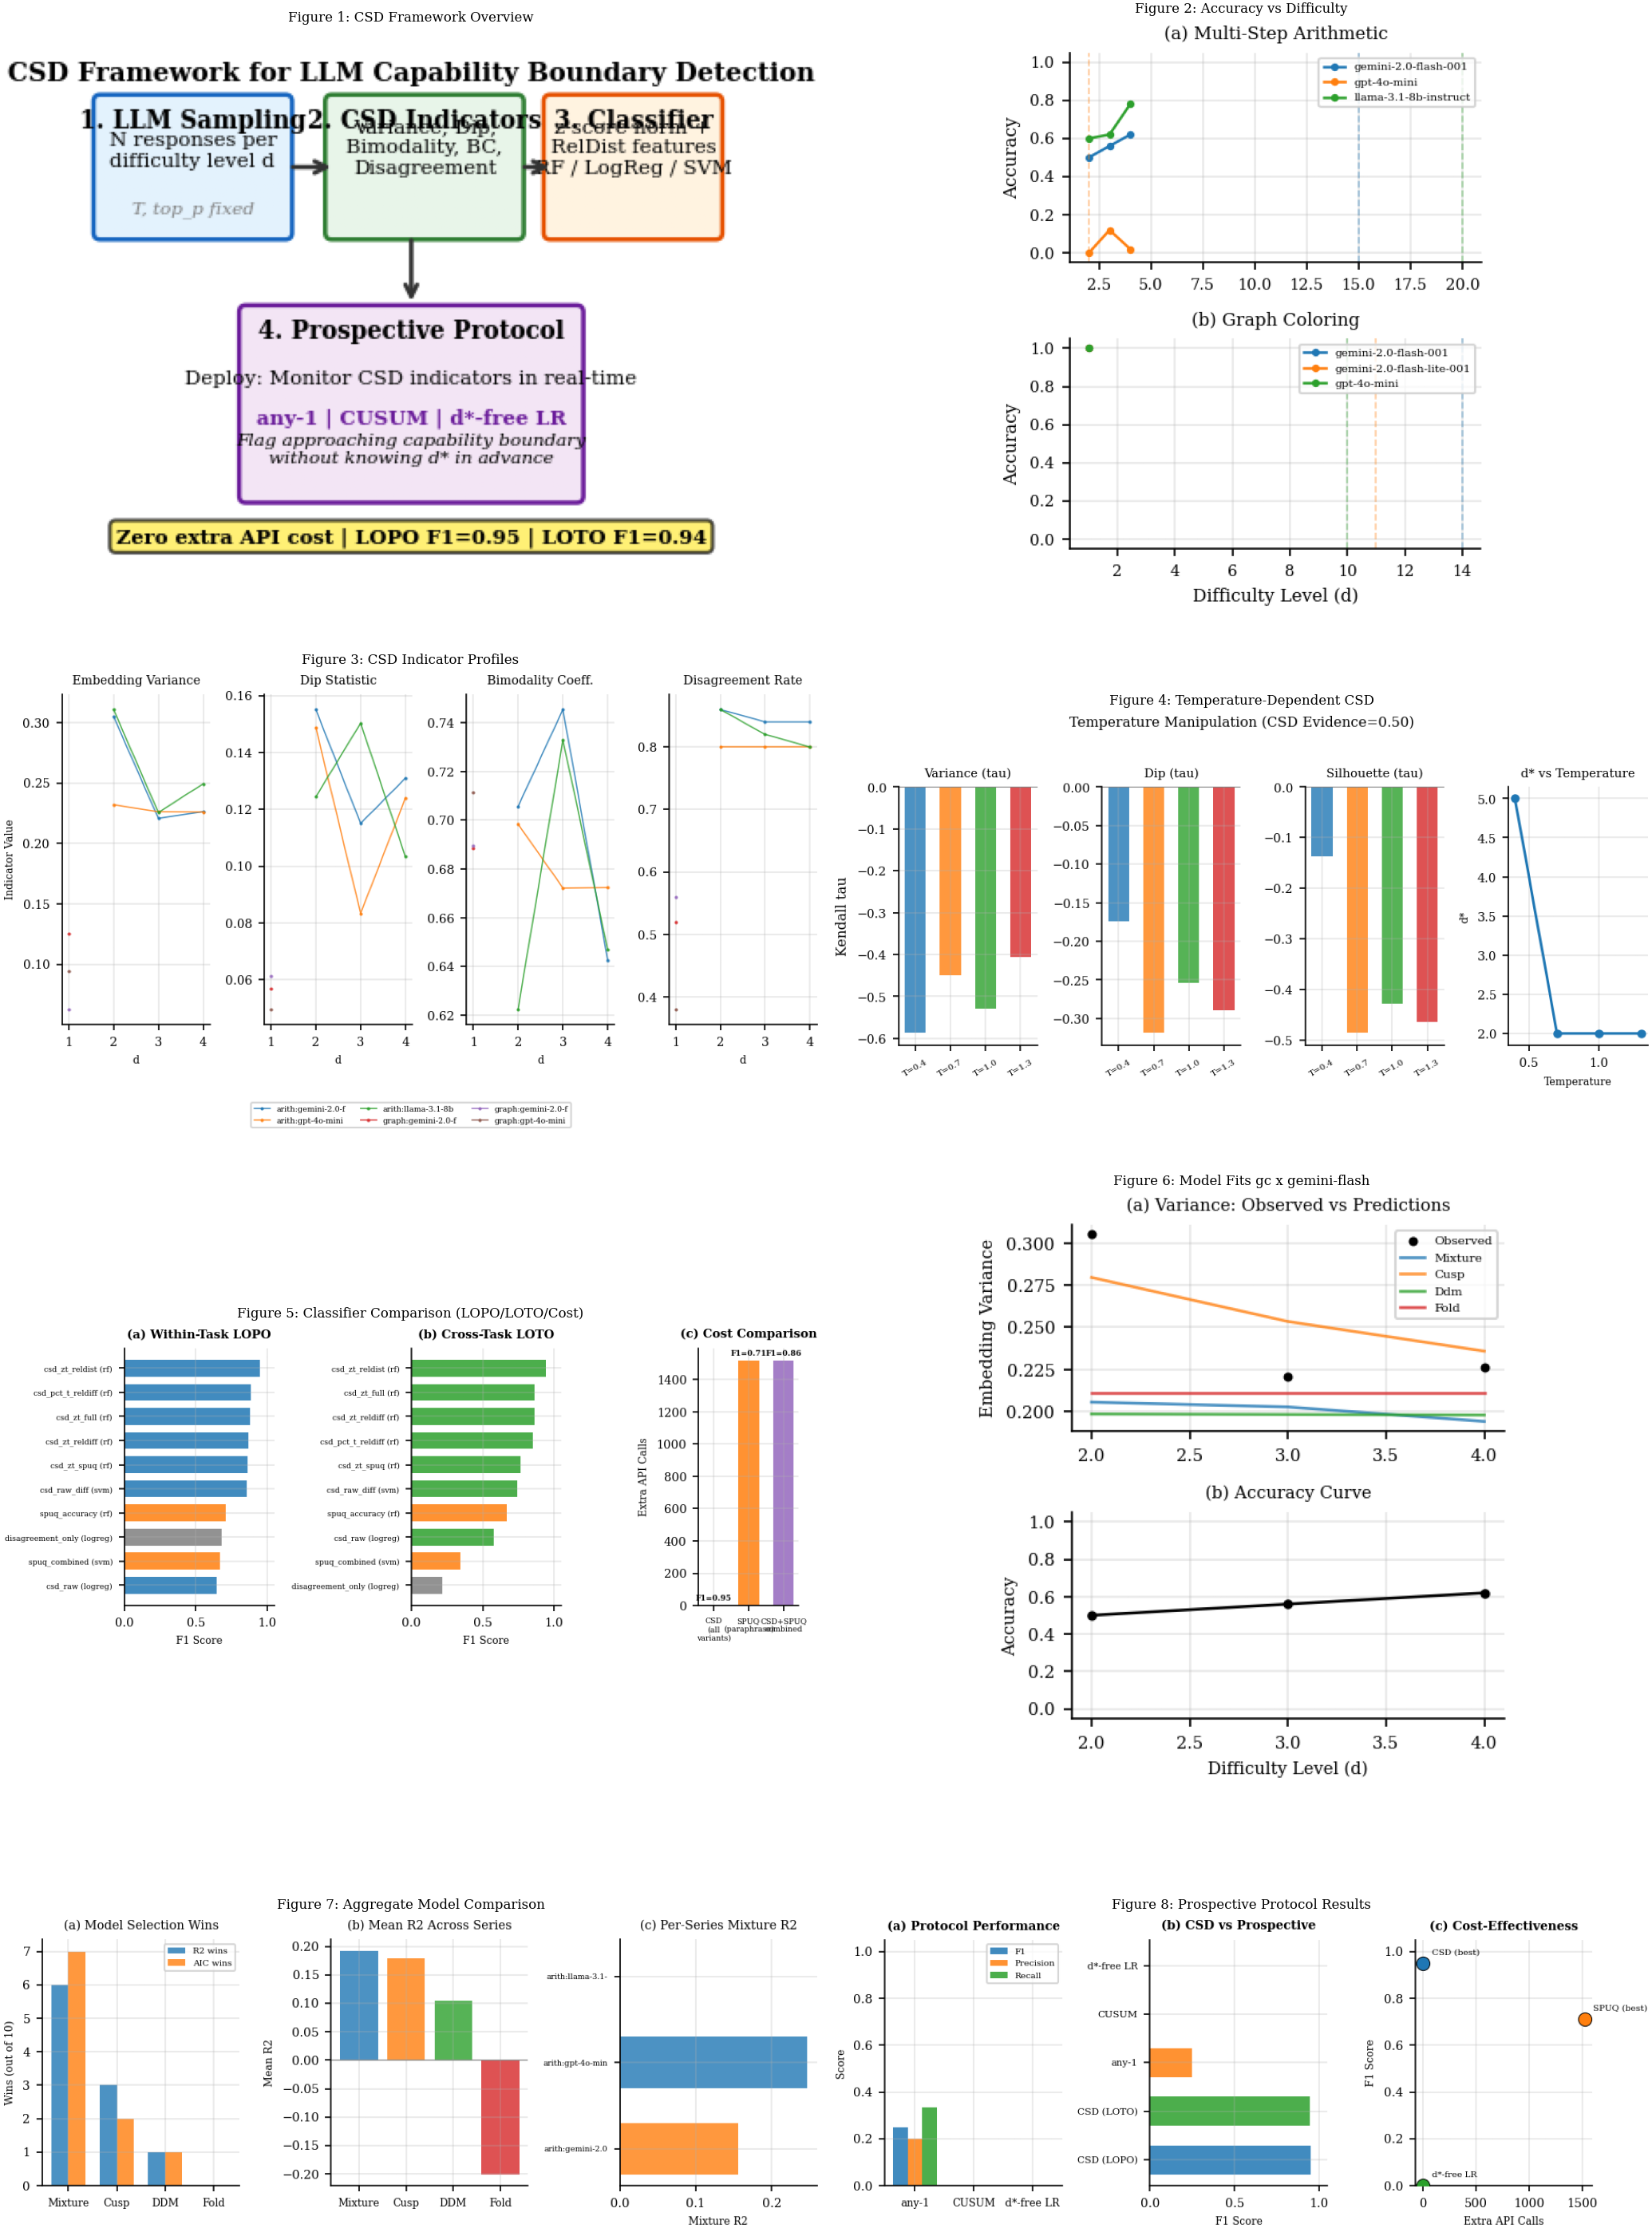


Done! 8 figures generated, 149 data points plotted.


In [11]:
# ── Summary Table ──
print(f"{'Figure':<45} {'Gen':>3} {'Size(KB)':>8} {'Width':>6} {'Height':>6} {'DimOK':>5} {'Points':>6}")
print("-" * 85)
for r in results:
    print(f"{r['input']:<45} "
          f"{'Y' if r['eval_figure_generated'] else 'N':>3} "
          f"{r['eval_filesize_png_kb']:>8.1f} "
          f"{r['eval_width_inches']:>6.2f} "
          f"{r['eval_height_inches']:>6.2f} "
          f"{'Y' if r['eval_dimension_compliance'] else 'N':>5} "
          f"{r['eval_n_data_points']:>6}")
print("-" * 85)
print(f"{'TOTALS':<45} {metrics_agg['total_figures_generated']:>3} "
      f"{metrics_agg['mean_filesize_png_kb']:>8.1f} "
      f"{'':>6} {'':>6} "
      f"{'Y' if metrics_agg['neurips_dimension_compliance'] else 'N':>5} "
      f"{metrics_agg['total_data_points_plotted']:>6}")

# ── Figure Gallery ──
n_figs = len([r for r in results if r["eval_figure_generated"]])
if n_figs > 0:
    cols = min(2, n_figs)
    rows_needed = math.ceil(n_figs / cols)
    fig_g, axes_g = plt.subplots(rows_needed, cols, figsize=(7 * cols, 5 * rows_needed))
    if rows_needed == 1 and cols == 1:
        axes_g = np.array([axes_g])
    axes_flat = axes_g.flatten() if hasattr(axes_g, 'flatten') else [axes_g]
    idx = 0
    for r in results:
        if not r["eval_figure_generated"]:
            continue
        png_path = FIGURES_DIR / f"{r['input'].split(':')[0].lower().replace(' ', '')}.png"
        # Use actual saved path
        actual_name = r["output"].split("/")[-1]
        actual_path = FIGURES_DIR / actual_name
        if actual_path.exists() and idx < len(axes_flat):
            img = plt.imread(str(actual_path))
            axes_flat[idx].imshow(img)
            axes_flat[idx].set_title(r["input"], fontsize=8)
            axes_flat[idx].axis("off")
            idx += 1
    # Hide unused axes
    for j in range(idx, len(axes_flat)):
        axes_flat[j].axis("off")
    fig_g.tight_layout()
    plt.show()

print(f"\nDone! {metrics_agg['total_figures_generated']} figures generated, "
      f"{metrics_agg['total_data_points_plotted']} data points plotted.")